## 特征编码

In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

df_preprocessed = pd.read_excel("../data/Telco_customer_churn_preprocessed.xlsx")
df_preprocessed.head()

,性别,老年人,伴侣,家属,在网时长（月）,电话服务,多条线路,互联网服务,网络安全,网络备份,设备保护,技术支持,流媒体电视,流媒体电影,合同类型,无纸化账单,支付方式,月费用,总费用,流失值,客户终身价值
0,Male,No,No,No,-1.236724,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,-0.362660,-0.958066,1,-0.981675
1,Female,No,No,Yes,-1.236724,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,0.197365,-0.938874,1,-1.436462
2,Female,No,No,Yes,-0.992402,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,1.159546,-0.643789,1,0.821409
3,Female,No,Yes,Yes,-0.177995,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,1.330711,0.338085,1,0.509483
4,Male,No,No,Yes,0.677133,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),1.294151,1.216150,1,0.794358


In [2]:
import pandas as pd
import numpy as np

df_encode = df_preprocessed.copy()

# ==========================================
# 1. 二元编码 (Binary Encoding)
# ==========================================
# 针对：Gender, Partner, Dependents, PaperlessBilling, PhoneService, 老年人
# 以及其他的 Yes/No 服务列 (需要先清洗 No internet service)

# A. 清洗 "No internet service" / "No phone service" -> "No"
service_cols = ['多条线路', '网络安全', '网络备份', '设备保护', 
                '技术支持', '流媒体电视', '流媒体电影']
for col in service_cols:
    df_encode[col] = df_encode[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# B. 定义二元映射
binary_mapping = {'Yes': 1, 'No': 0}
gender_mapping = {'Male': 1, 'Female': 0}

# C. 应用映射
binary_vars = ['伴侣', '家属', '无纸化账单', '电话服务', '老年人'] + service_cols
for col in binary_vars:
    df_encode[col] = df_encode[col].map(binary_mapping)

df_encode['性别'] = df_encode['性别'].map(gender_mapping)


# ==========================================
# 2. 服务层级序数编码 (Ordinal Encoding for Service Tiers)
# ==========================================
# 映射逻辑: Fiber optic (最强) -> 2, DSL (次之) -> 1, No (无) -> 0
internet_mapping = {
    'Fiber optic': 2,
    'DSL': 1,
    'No': 0
}
df_encode['互联网服务'] = df_encode['互联网服务'].map(internet_mapping)


# ==========================================
# 3. 合同期限时间归一化 (Temporal Normalization)
# ==========================================
# 映射逻辑: 将合同长度标准化为“年”单位
# Two year -> 2.0
# One year -> 1.0
# Month-to-month -> 1/12 ≈ 0.083
contract_mapping = {
    'Two year': 2.0,
    'One year': 1.0,
    'Month-to-month': 0.083
}
df_encode['合同类型'] = df_encode['合同类型'].map(contract_mapping)


# ==========================================
# 4. 支付方式降维合并 (Payment Method Consolidation)
# ==========================================
# 映射逻辑: 
# 自动扣款 (Bank transfer, Credit card) -> 1 (低流失风险，粘性强)
# 主动支付 (Electronic check, Mailed check) -> 0 (高流失风险，粘性弱)

def encode_payment(method):
    if 'automatic' in method: # 包含 (automatic) 字样的是 Bank transfer 和 Credit card
        return 1
    else: # Electronic check 和 Mailed check
        return 0

df_encode['支付方式'] = df_encode['支付方式'].apply(encode_payment)

print("\n数据类型检查:")
print(df_encode.dtypes)

print("编码后数据预览：")
df_encode.head()


数据类型检查:
性别           int64
老年人          int64
伴侣           int64
家属           int64
在网时长（月）    float64
电话服务         int64
多条线路         int64
互联网服务        int64
网络安全         int64
网络备份         int64
设备保护         int64
技术支持         int64
流媒体电视        int64
流媒体电影        int64
合同类型       float64
无纸化账单        int64
支付方式         int64
月费用        float64
总费用        float64
流失值          int64
客户终身价值     float64
dtype: object
编码后数据预览：


,性别,老年人,伴侣,家属,在网时长（月）,电话服务,多条线路,互联网服务,网络安全,网络备份,设备保护,技术支持,流媒体电视,流媒体电影,合同类型,无纸化账单,支付方式,月费用,总费用,流失值,客户终身价值
0,1,0,0,0,-1.236724,1,0,1,1,1,0,0,0,0,0.083,1,0,-0.362660,-0.958066,1,-0.981675
1,0,0,0,1,-1.236724,1,0,2,0,0,0,0,0,0,0.083,1,0,0.197365,-0.938874,1,-1.436462
2,0,0,0,1,-0.992402,1,1,2,0,0,1,0,1,1,0.083,1,0,1.159546,-0.643789,1,0.821409
3,0,0,1,1,-0.177995,1,1,2,0,0,1,1,1,1,0.083,1,0,1.330711,0.338085,1,0.509483
4,1,0,0,1,0.677133,1,1,2,0,1,1,0,1,1,0.083,1,1,1.294151,1.216150,1,0.794358


## 特征选择

In [3]:
# %pip install Boruta

In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

X = df_encode.drop(['流失值'], axis=1).values
y = df_encode['流失值'].values
feature_names = np.array(df_encode.drop(['流失值'], axis=1).columns)

# ==========================================
# Report Part 1: 方法论配置 (Methodology / Hyperparameters)
# ==========================================
# 这些参数是你报告中 "Experimental Setup" 章节需要列出的
rf_params = {
    'n_jobs': -1,
    'class_weight': 'balanced',
    'max_depth': 5,  # 限制深度以防过拟合
    'random_state': 42
}

boruta_params = {
    'n_estimators': 'auto',
    'verbose': 0, # 静默模式
    'random_state': 42,
    'perc': 100,  # 严格模式：特征必须强于100%的影子特征才算选中 (相当于 p < 0.01 的严格度)
    'max_iter': 100 # 最大迭代次数
}

print("--- 1. 模型超参数配置 (用于报告方法论部分) ---")
print(f"基分类器: Random Forest Classifier")
print(f"RF 参数: {rf_params}")
print(f"Boruta 参数: {boruta_params}")
print("-" * 50)

rf = RandomForestClassifier(**rf_params)
feat_selector = BorutaPy(rf, **boruta_params)
feat_selector.fit(X, y)


# ==========================================
# Report Part 2: 统计结果表 (Results)
# ==========================================
# 提取特征重要性数值 (这是 Boruta 内部最后一次迭代 RF 的 Feature Importance)
# 这代表了“效应量” (Effect Size)
n_feats = len(feature_names)
feature_importances = feat_selector.estimator.feature_importances_[:n_feats]

# 构建详细报告表
report_df = pd.DataFrame({
    'Feature (特征)': feature_names,
    'Importance (重要性得分)': feature_importances, # 类似于回归系数或效应量
    'Rank (排名)': feat_selector.ranking_,
    'Status (最终决策)': ['Confirmed (保留)' if x else 'Rejected (剔除)' for x in feat_selector.support_]
})

# 按重要性降序排列，方便查看谁最重要
report_df = report_df.sort_values(by='Importance (重要性得分)', ascending=False).reset_index(drop=True)

# 标记 Tentative (如果在最大迭代后仍未决断，排名通常不是1但也不是最差，这里统称剔除以简化)
# BorutaPy 默认如果不确定会放入 Tentative，这里我们只关注 Confirmed

print("\n--- 2. 特征选择统计报告 (用于报告结果部分) ---")
print(report_df)

# ==========================================
# Report Part 3: 最终特征列表
# ==========================================
final_features = feature_names[feat_selector.support_].tolist()
print(f"\n最终入选特征数量: {len(final_features)} / {len(feature_names)}")
print(f"入选特征列表: {final_features}")

--- 1. 模型超参数配置 (用于报告方法论部分) ---
基分类器: Random Forest Classifier
RF 参数: {'n_jobs': -1, 'class_weight': 'balanced', 'max_depth': 5, 'random_state': 42}
Boruta 参数: {'n_estimators': 'auto', 'verbose': 0, 'random_state': 42, 'perc': 100, 'max_iter': 100}
--------------------------------------------------

--- 2. 特征选择统计报告 (用于报告结果部分) ---
   Feature (特征)  Importance (重要性得分)  Rank (排名)   Status (最终决策)
0          网络备份            0.257486          2   Rejected (剔除)
1            家属            0.157837          1  Confirmed (保留)
2       在网时长（月）            0.130136          1  Confirmed (保留)
3            伴侣            0.113886          1  Confirmed (保留)
4         流媒体电视            0.086337          1  Confirmed (保留)
5         流媒体电影            0.080598          1  Confirmed (保留)
6          技术支持            0.031522          1  Confirmed (保留)
7          设备保护            0.029568          5   Rejected (剔除)
8          电话服务            0.022953          4   Rejected (剔除)
9          多条线路            0.020632    


Boruta 特征选择结果：
         特征  排名         状态
19   客户终身价值   1  Confirmed
1       老年人   1  Confirmed
2        伴侣   1  Confirmed
3        家属   1  Confirmed
4   在网时长（月）   1  Confirmed
17      月费用   1  Confirmed
16     支付方式   1  Confirmed
7     互联网服务   1  Confirmed
8      网络安全   1  Confirmed
18      总费用   1  Confirmed
15    无纸化账单   1  Confirmed
11     技术支持   1  Confirmed
12    流媒体电视   1  Confirmed
13    流媒体电影   1  Confirmed
14     合同类型   1  Confirmed
9      网络备份   2   Rejected
6      多条线路   3   Rejected
5      电话服务   4   Rejected
10     设备保护   5   Rejected
0        性别   6   Rejected


C:\Users\lincaicai\AppData\Local\Temp\ipykernel_28444\2879154631.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='排名', y='特征', data=results_df, palette=colors)


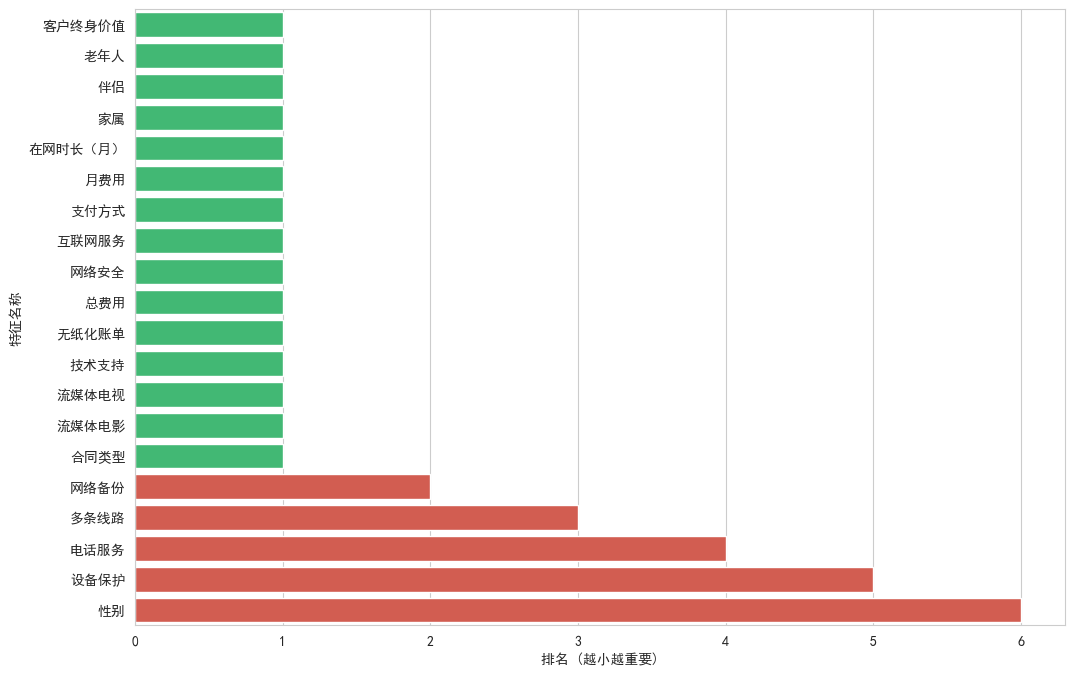

In [7]:
results_df = pd.DataFrame({
    '特征': feature_names,
    '排名': feat_selector.ranking_,
    '状态': ['Confirmed' if x else 'Rejected' for x in feat_selector.support_]
})

results_df.loc[results_df['排名'] > 1, '状态'] = 'Rejected'

results_df = results_df.sort_values(by='排名')

print("\nBoruta 特征选择结果：")
print(results_df)

plt.figure(figsize=(12, 8))

colors = ['#2ecc71' if x == 1 else '#e74c3c' for x in results_df['排名']]

sns.barplot(x='排名', y='特征', data=results_df, palette=colors)
plt.xlabel('排名 (越小越重要)')
plt.ylabel('特征名称')
plt.show()

In [8]:
final_features = feature_names[feat_selector.support_].tolist()

print(f"✅ 最终选定入模特征 ({len(final_features)}个):")
print(final_features)

df_model = df_encode[final_features + ['流失值']].copy()

# 保存一份最终清洗好的数据，方便后续直接读取跑模型
df_model.to_excel("../data/Telco_customer_churn_final_model.xlsx", index=False)

✅ 最终选定入模特征 (15个):
['老年人', '伴侣', '家属', '在网时长（月）', '互联网服务', '网络安全', '技术支持', '流媒体电视', '流媒体电影', '合同类型', '无纸化账单', '支付方式', '月费用', '总费用', '客户终身价值']
